# Blatt 7



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)


In [19]:
file_path = "herford_weather.csv"
df = pd.read_csv(file_path)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)
df.head()


,time,temperature_2m (°C),relativehumidity_2m (%),dewpoint_2m (°C),apparent_temperature (°C),pressure_msl (hPa),surface_pressure (hPa),precipitation (mm),rain (mm),snowfall (cm),...,et0_fao_evapotranspiration (mm),vapor_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,1996-01-01 00:00:00,-2.3,80,-5.3,-7.2,1003.4,988.2,0.0,0.0,0.0,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1,1996-01-01 01:00:00,-2.1,80,-5.2,-7.0,1003.8,988.6,0.0,0.0,0.0,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
2,1996-01-01 02:00:00,-2.0,79,-5.2,-6.9,1003.9,988.7,0.0,0.0,0.0,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
3,1996-01-01 03:00:00,-2.1,79,-5.3,-7.0,1004.0,988.8,0.0,0.0,0.0,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
4,1996-01-01 04:00:00,-2.2,78,-5.5,-7.1,1004.5,989.3,0.0,0.0,0.0,...,0.01,0.12,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34


## Aufgabe 1a - Datenanalyse


In [20]:
all_features = [
    "temperature_2m (°C)",
    "relativehumidity_2m (%)",
    "dewpoint_2m (°C)",
    "apparent_temperature (°C)",
    "pressure_msl (hPa)",
    "surface_pressure (hPa)",
    "precipitation (mm)",
    "rain (mm)",
    "snowfall (cm)",
    "weathercode (wmo code)",
    "cloudcover (%)",
    "cloudcover_low (%)",
    "cloudcover_mid (%)",
    "cloudcover_high (%)",
    "shortwave_radiation (W/m²)",
    "direct_radiation (W/m²)",
    "diffuse_radiation (W/m²)",
    "direct_normal_irradiance (W/m²)",
    "windspeed_10m (km/h)",
    "windspeed_100m (km/h)",
    "winddirection_10m (°)",
    "winddirection_100m (°)",
    "windgusts_10m (km/h)",
    "et0_fao_evapotranspiration (mm)",
    "vapor_pressure_deficit (kPa)",
    "soil_temperature_0_to_7cm (°C)",
    "soil_temperature_7_to_28cm (°C)",
    "soil_temperature_28_to_100cm (°C)",
    "soil_temperature_100_to_255cm (°C)",
    "soil_moisture_0_to_7cm (m³/m³)",
    "soil_moisture_7_to_28cm (m³/m³)",
    "soil_moisture_28_to_100cm (m³/m³)",
    "soil_moisture_100_to_255cm (m³/m³)",
]

target_dewpoint = "dewpoint_2m (°C)"


In [21]:
df[all_features].isna().sum().sort_values(ascending=False).head(10)


temperature_2m (°C)                   0
direct_normal_irradiance (W/m²)       0
soil_moisture_28_to_100cm (m³/m³)     0
soil_moisture_7_to_28cm (m³/m³)       0
soil_moisture_0_to_7cm (m³/m³)        0
soil_temperature_100_to_255cm (°C)    0
soil_temperature_28_to_100cm (°C)     0
soil_temperature_7_to_28cm (°C)       0
soil_temperature_0_to_7cm (°C)        0
vapor_pressure_deficit (kPa)          0
dtype: int64

In [23]:
df[all_features].describe().T


,count,mean,std,min,25%,50%,75%,max
temperature_2m (°C),239570.0,10.265707,7.419092,-20.800,4.800,10.200,15.700,36.400
relativehumidity_2m (%),239570.0,78.152448,14.996915,21.000,68.000,81.000,90.000,100.000
dewpoint_2m (°C),239570.0,6.261274,6.240075,-22.700,2.100,6.600,11.000,23.800
apparent_temperature (°C),239570.0,7.768561,8.888222,-26.100,1.000,7.400,14.400,39.000
pressure_msl (hPa),239570.0,1015.593982,9.615801,965.400,1009.800,1016.100,1021.900,1048.000
surface_pressure (hPa),239570.0,1000.900051,9.447970,951.200,995.300,1001.500,1007.100,1032.500
precipitation (mm),239570.0,0.084380,0.281955,0.000,0.000,0.000,0.000,12.300
rain (mm),239570.0,0.079933,0.277272,0.000,0.000,0.000,0.000,12.300
snowfall (cm),239570.0,0.003422,0.033343,0.000,0.000,0.000,0.000,1.890
weathercode (wmo code),239570.0,11.555524,20.858637,0.000,1.000,2.000,3.000,75.000


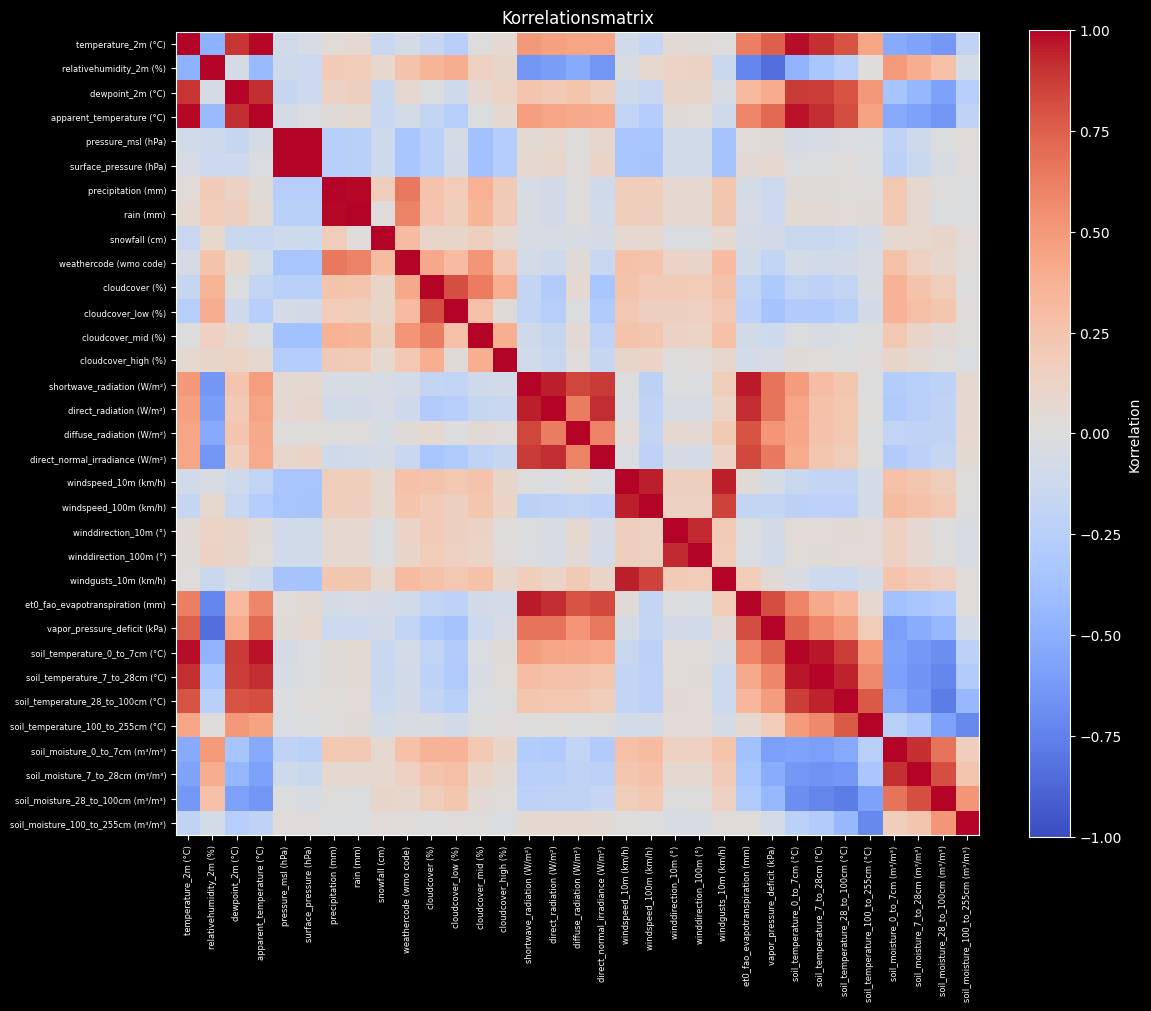

In [22]:
corr = df[all_features].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Korrelation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
plt.title("Korrelationsmatrix")
plt.tight_layout()


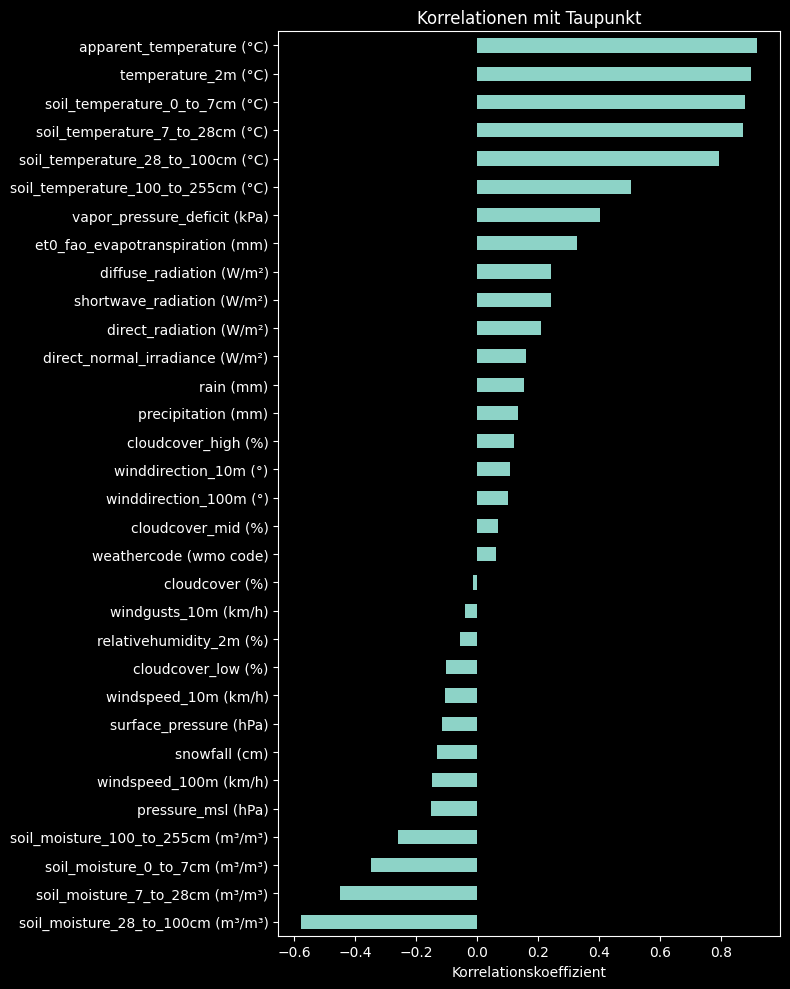

In [24]:
corr_target = corr[target_dewpoint].drop(target_dewpoint).sort_values()

plt.figure(figsize=(8, 10))
corr_target.plot(kind="barh")
plt.title("Korrelationen mit Taupunkt")
plt.xlabel("Korrelationskoeffizient")
plt.tight_layout()


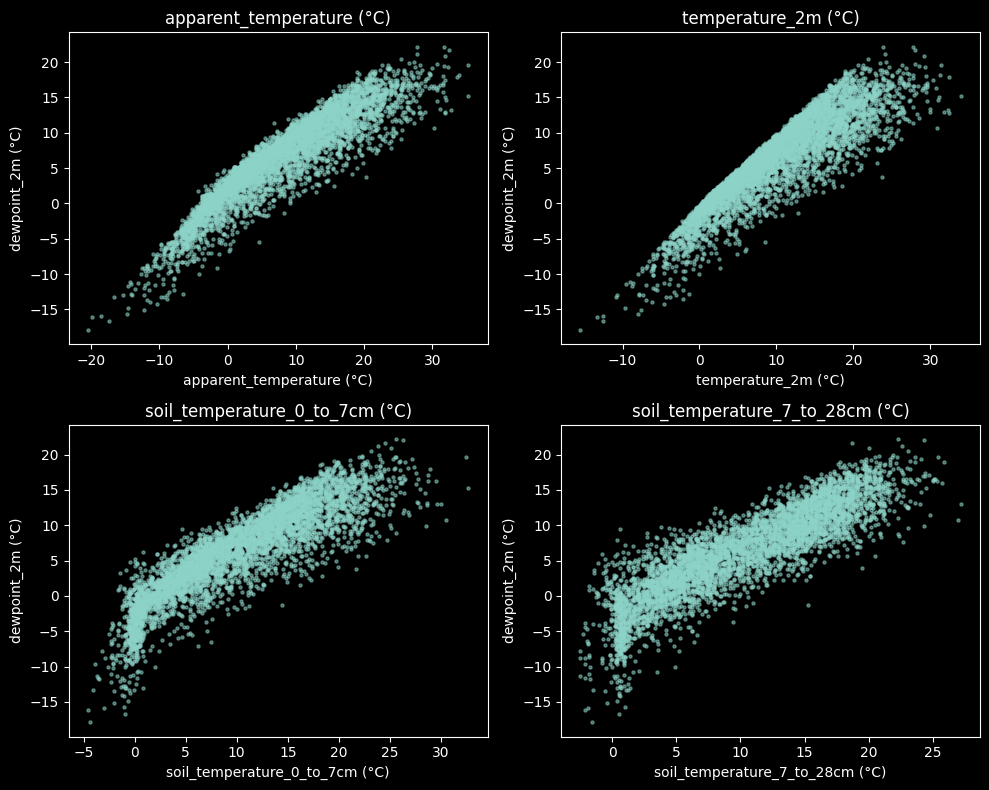

In [36]:
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
sample_df = df.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, col in zip(axes, top_features):
    ax.scatter(sample_df[col], sample_df[target_dewpoint], s=5, alpha=0.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel(target_dewpoint)
plt.tight_layout()


In [26]:
selected_features = [
    "temperature_2m (°C)",
    "apparent_temperature (°C)",
    "soil_temperature_0_to_7cm (°C)",
    "soil_temperature_7_to_28cm (°C)",
    "soil_temperature_28_to_100cm (°C)",
    "vapor_pressure_deficit (kPa)",
    "soil_moisture_28_to_100cm (m³/m³)",
]
selected_features


['temperature_2m (°C)',
 'apparent_temperature (°C)',
 'soil_temperature_0_to_7cm (°C)',
 'soil_temperature_7_to_28cm (°C)',
 'soil_temperature_28_to_100cm (°C)',
 'vapor_pressure_deficit (kPa)',
 'soil_moisture_28_to_100cm (m³/m³)']

## Aufgabe 1b - 1e: Skalierung, Modell, Training, R2 und Lernkurve


In [40]:
def split_and_scale(df, features, target, test_size=0.2, val_size=0.2, random_state=42):
    X = df[features].values
    y = df[target].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return scaler, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test


def build_linear_model(input_dim, learning_rate=1e-3):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(input_dim,)),
            keras.layers.Dense(1),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )
    return model


def train_grid(X_train, y_train, X_val, y_val, params_list):
    results = []
    best = None
    for params in params_list:
        model = build_linear_model(
            X_train.shape[1],
            learning_rate=params.get("learning_rate", 1e-3),
        )
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0,
        )
        val_pred = model.predict(X_val, verbose=0).ravel()
        val_r2 = r2_score(y_val, val_pred)
        val_loss = history.history["val_loss"][-1]
        row = {
            "epochs": params["epochs"],
            "batch_size": params["batch_size"],
            "val_loss": val_loss,
            "val_r2": val_r2,
            "model": model,
            "history": history,
        }
        results.append(row)
        if best is None or val_loss < best["val_loss"]:
            best = row

    results_df = (
        pd.DataFrame(results)
        .drop(columns=["model", "history"])
        .sort_values("val_loss")
        .reset_index(drop=True)
    )
    return results_df, best


In [54]:
param_grid = [
    {"epochs": 10, "batch_size": 256, "learning_rate": 1e-3},
    {"epochs": 20, "batch_size": 256, "learning_rate": 1e-3},
    {"epochs": 40, "batch_size": 256, "learning_rate": 1e-3},
    {"epochs": 20, "batch_size": 512, "learning_rate": 1e-3},
]

scaler, X_train, X_val, X_test, y_train, y_val, y_test = split_and_scale(
    df, selected_features, target_dewpoint
)

results_df, best = train_grid(X_train, y_train, X_val, y_val, param_grid)
results_df


,epochs,batch_size,val_loss,val_r2
0,40,256,1.354628,0.964838
1,20,256,1.403858,0.963560
2,20,512,3.557363,0.907662
3,10,256,4.096083,0.893679


## d)

In [56]:
test_pred = best["model"].predict(X_test, verbose=2).ravel()
test_r2 = r2_score(y_test, test_pred)
test_r2


1498/1498 - 0s - 229us/step


0.9651448389576062

## e)

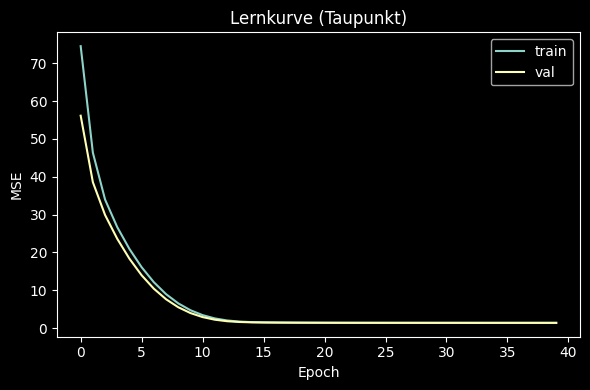

In [43]:
history = best["history"]

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Lernkurve (Taupunkt)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()


## f)


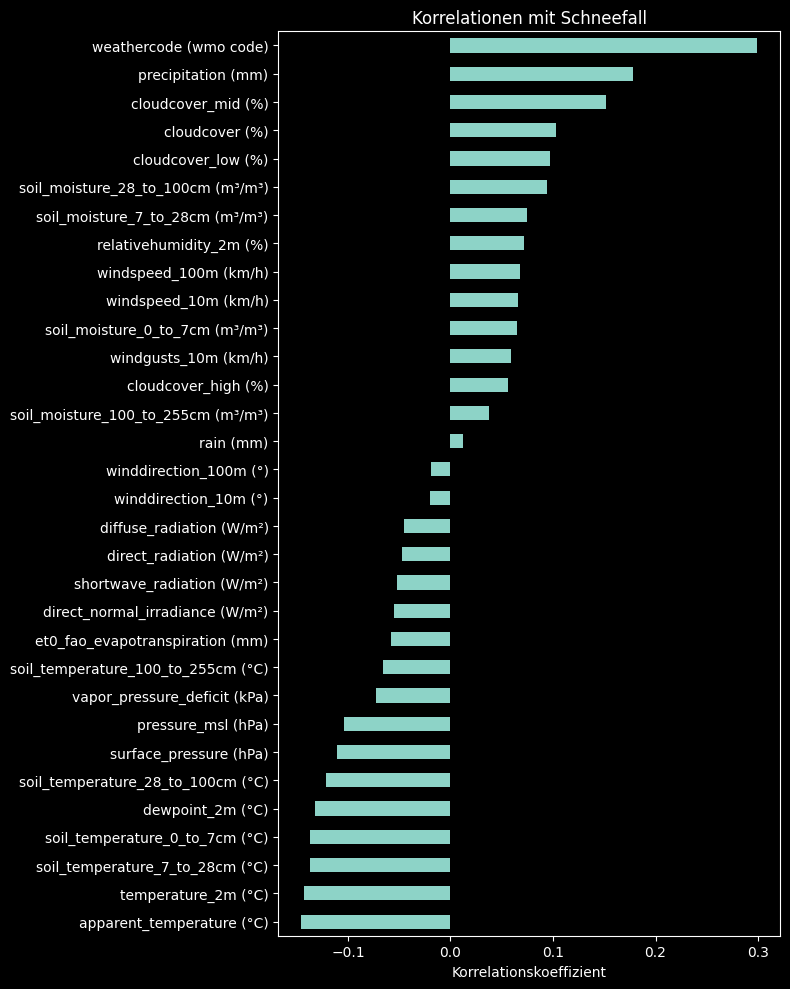

In [31]:
target_snow = "snowfall (cm)"

corr_snow = (
    df[all_features]
    .corr(numeric_only=True)[target_snow]
    .drop(target_snow)
    .sort_values()
)

plt.figure(figsize=(8, 10))
corr_snow.plot(kind="barh")
plt.title("Korrelationen mit Schneefall")
plt.xlabel("Korrelationskoeffizient")
plt.tight_layout()


In [32]:
snow_features = [
    "weathercode (wmo code)",
    "precipitation (mm)",
    "cloudcover_mid (%)",
    "temperature_2m (°C)",
    "apparent_temperature (°C)",
    "soil_temperature_7_to_28cm (°C)",
    "dewpoint_2m (°C)",
]

snow_features


['weathercode (wmo code)',
 'precipitation (mm)',
 'cloudcover_mid (%)',
 'temperature_2m (°C)',
 'apparent_temperature (°C)',
 'soil_temperature_7_to_28cm (°C)',
 'dewpoint_2m (°C)']

In [33]:
scaler_snow, X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_and_scale(
    df, snow_features, target_snow
)

results_snow_df, best_snow = train_grid(
    X_train_s, y_train_s, X_val_s, y_val_s, param_grid
)
results_snow_df


,epochs,batch_size,val_loss,val_r2
0,10,256,0.001096,0.110452
1,40,256,0.001103,0.104734
2,20,256,0.001104,0.103890
3,20,512,0.001115,0.095206


In [34]:
snow_pred = best_snow["model"].predict(X_test_s, verbose=0).ravel()
snow_r2 = r2_score(y_test_s, snow_pred)
snow_r2


0.11851411714369975

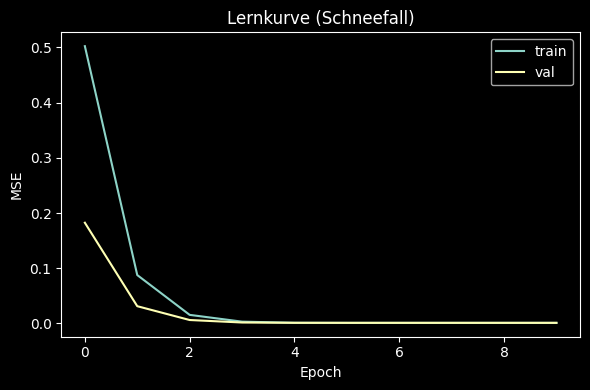

In [35]:
history_snow = best_snow["history"]

plt.figure(figsize=(6, 4))
plt.plot(history_snow.history["loss"], label="train")
plt.plot(history_snow.history["val_loss"], label="val")
plt.title("Lernkurve (Schneefall)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
